# **Taller 1: Fundamentos de R y Diseño Experimental**

**Curso: Aplicaciones Estadísticas**

**Instructor:** Paul Lopez

###**En este taller aprenderemos a navegar en el entorno de R, realizar cálculos básicos, describir datos y entender la base del diseño experimental: la variación**



### **1.1 Primeros pasos y asignación**

R puede ser usado como una calculadora.


### **1.1.1 Operaciones Básicas**



In [ ]:
# Suma
5 + 3

# Multiplicación (usamos el asterisco *)
4 * 6

# División (usamos la barra /)
20 / 4

# Cálculo complejo respetando paréntesis
(10 + 5) * 2

[1] 8

[1] 24

[1] 5

[1] 30

### **1.2 MÓDULO INTRODUCTORIO: Fundamentos de R para Diseño Experimental**

Antes de comenzar con los análisis de varianza, revisaremos las nociones básicas de R necesarias para manipular datos experimentales.

### 1. Variables y Asignación
En R, para guardar un valor dentro de un objeto (variable), se utiliza el operador de asignación `<-` (flecha hacia la izquierda).

### 2. Tipos de Datos Clave en Diseños Experimentales
* **Numérico (numeric):** Valores decimales o enteros (ej. peso de frutos, altura de planta).
* **Factor (factor):** Representa variables categóricas o cualitativas (ej. dosis de fertilizante, tipo de suelo, bloques). **Es indispensable que las variables de tratamiento estén definidas como factor en R para que el ANOVA funcione correctamente.**
* **Data Frame (data.frame):** Es una tabla o matriz de datos donde las columnas son variables y las filas son observaciones.

---
### Ejercicio Práctico 1: ¡Tu turno de completar!
En la siguiente celda de código, debes rellenar los espacios vacíos señalados con `___` para crear un pequeño conjunto de datos experimentales.

In [ ]:
# --- EJERCICIO DE ASIGNACIÓN Y FACTORES ---

# 1. Crea un vector numérico con los pesos de 6 plantas (completa el espacio):
pesos <- c(12.5, 14.2, 11.8, 15.1, 13.9, 14.5)

# 2. Crea un vector con los nombres de los tratamientos (Control y Tratamiento1):
# Completa el espacio dentro de c() para asignar los tratamientos
tratamientos_crudos <- c("Control", "Control", "Control", "Trat1", "Trat1", "Trat1")

# 3. Convierte el vector de tratamientos a un FACTOR (indispensable para el ANOVA):
# RELLENA EL ESPACIO: Reemplaza ___ con el nombre del vector que creamos en el paso anterior.
tratamientos_factor <- factor(tratamientos_crudos)

# 4. Agrupa ambos vectores en una tabla (Data Frame):
# RELLENA EL ESPACIO: Reemplaza ___ con las variables 'tratamientos_factor' y 'pesos'.
mis_datos <- data.frame(
  Tratamiento = tratamientos_factor,
  Peso_Fruto = pesos
)

# Imprime los datos creados
print("Estructura de la tabla creada:")
print(mis_datos)

In [ ]:
# En Google Colab R, instalamos los paquetes necesarios para la visualización y análisis de supuestos.
# Usaremos el ecosistema 'easystats' que incluye 'performance' y 'see'.
install.packages("performance")
install.packages("see")
install.packages("ggplot2")

# Cargamos las librerías
library(ggplot2)
library(performance)
library(see)

cat("Entorno de R configurado con éxito.\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bayestestR’, ‘insight’, ‘datawizard’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘correlation’, ‘effectsize’, ‘modelbased’, ‘patchwork’, ‘parameters’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Entorno de R configurado con éxito.


# MÓDULO: Cómo importar tus propios datos desde Excel o CSV

En la práctica, recolectarás tus datos en programas como Microsoft Excel. Sigue estos pasos para subirlos y analizarlos en Google Colab:

### Paso 1: Subir el archivo a Google Colab
1. Ve al panel izquierdo de Google Colab y haz clic en el icono de **Carpeta (Archivos)**.
2. Haz clic en el botón **Subir al almacenamiento de sesión** (icono de hoja con una flecha hacia arriba).
3. Selecciona tu archivo desde tu computadora (puede ser `.csv` o `.xlsx`).

### Paso 2: Importar usando código R
* Si tu archivo es un **CSV**, utilizaremos la función `read.csv()`.
* Si tu archivo es un **Excel (.xlsx)**, instalaremos y utilizaremos la librería `readxl`.

---

### Ejercicio Práctico 2: ¡Completa el código para importar!
Sube un archivo de prueba o utiliza la plantilla del ejercicio sustituyendo los nombres indicados por `___`.

In [ ]:
# --- IMPORTACIÓN DE ARCHIVOS ---

# Opción A: Importar un archivo en formato CSV
# Instrucción: Reemplaza "___" con el nombre exacto de tu archivo subido en Colab (ej. "datos_campo.csv")
# y el parámetro sep con el separador de columnas adecuado (usualmente "," o ";").

mi_csv <- read.csv("___", sep = ",")


# Opción B: Importar un archivo en formato Excel (.xlsx)
# Primero instalamos la librería necesaria
install.packages("readxl")
library(readxl)

# Instrucción: Reemplaza "___" con el nombre exacto de tu archivo de Excel (ej. "experimento.xlsx")
mi_excel <- read_excel("___")


# Visualizar las primeras filas de los datos importados (reemplaza ___ con 'mi_csv' o 'mi_excel')
head(___)

# Bienvenidos al Laboratorio de Diseño Experimental con R

Para dominar el análisis de datos no necesitas ser programador, sino entender cómo R se comunica contigo.

En R, nos comunicamos usando **Funciones**. Una función es como una máquina de cocina:
* Tiene un **nombre** (la máquina: licuadora).
* Recibe **argumentos** (los ingredientes: frutas, leche).
* Entrega un **resultado** (el batido).

La sintaxis básica siempre es:
`nombre_de_funcion(argumento1 = valor1, argumento2 = valor2)`

### **1.2. Guardar información (Variables)**
En lugar de solo ver el resultado y perderlo, podemos guardarlo en la memoria de la computadora.
Para esto usamos el operador de asignación `<-` (una flecha hecha con el signo menor que y un guion).
Piensa en esto como meter un valor dentro de una caja y ponerle una etiqueta.

### LECCIÓN 1: La Fórmula y el Factor

En diseño experimental, el símbolo más importante es la **tilde de la fórmula (`~`)**.
Se lee como: *"En función de"* o *"Depende de"*.

* **Variable Dependiente (Y):** Lo que mides (ej. Peso del fruto). Va a la **izquierda** de la `~`.
* **Variable Independiente (X):** Tus tratamientos (ej. Fertilizante). Va a la **derecha** de la `~`.

Fórmula en R: `Peso ~ Fertilizante` (El Peso depende del Fertilizante).

---

#### Anatomía del comando para crear Datos:
* `data.frame(...)`: Función para crear una tabla de datos.
* `factor(...)`: Función que le dice a R: *"Esta columna no son solo letras, son mis tratamientos categóricos"*.

In [ ]:
# 1. Definimos los tratamientos usando la función 'rep' (repetir)
# rep("A", 5) significa: repite la letra "A" 5 veces.
tratamientos_repetidos <- c(rep("Bioestimulante_A", 5),
                            rep("Bioestimulante_B", 5),
                            rep("Control", 5))

# 2. Convertimos a factor (esencial para que el ANOVA sepa qué comparar)
variable_factor <- factor(tratamientos_repetidos)

# 3. Creamos las mediciones de altura (en centímetros)
valores_altura <- c(45.2, 46.8, 44.1, 45.9, 46.1,  # Bio A
                    52.1, 54.3, 51.5, 53.0, 52.8,  # Bio B
                    39.1, 40.5, 38.9, 41.2, 39.7)  # Control

# 4. Unimos todo en una tabla (data.frame)
datos_experimento <- data.frame(
  Tratamiento = variable_factor,
  Altura = valores_altura
)

# Visualizamos la tabla
print("Nuestra tabla de datos terminada:")
print(datos_experimento)

### LECCIÓN 2: Progresión Gráfica con `ggplot2`

Para entender cómo funciona `ggplot2`, construiremos el mismo gráfico en tres niveles de dificultad: **Sencillo**, **Intermedio** y **Avanzado**. Esto nos permite ver cómo cada línea de código adicional mejora la calidad visual y la interpretabilidad de los datos.

---

#### Nivel 1: El Gráfico Sencillo (Estructura Mínima)
Es el punto de partida. Solo requiere definir la base de datos, las variables de los ejes ($X$ e $Y$) y la forma geométrica (`geom_boxplot`).

* **Anatomía del código:**
  * `ggplot(datos, aes(x, y))` de donde R obtiene las coordenadas.
  * `+ geom_boxplot()` que le indica a R que dibuje las cajas de forma predeterminada (fondo gris, cajas blancas).

In [ ]:
# --- NIVEL 1: GRÁFICO BÁSICO ---
# El mínimo código necesario para visualizar los datos

ggplot(data = datos_experimento, aes(x = Tratamiento, y = Altura)) +
  geom_boxplot()

#### Nivel 2: El Gráfico Intermedio (Colores y Etiquetas)
El gráfico anterior es funcional, pero carece de color y utiliza los nombres técnicos de las variables del software como etiquetas de los ejes. En este nivel agregamos color a las cajas y personalizamos los textos.

* **Anatomía del código:**
  * `fill = Tratamiento` dentro de `aes()` asigna un color automático a cada grupo.
  * `labs(...)` (labels) permite cambiar los títulos para que sean comprensibles para el público en general.

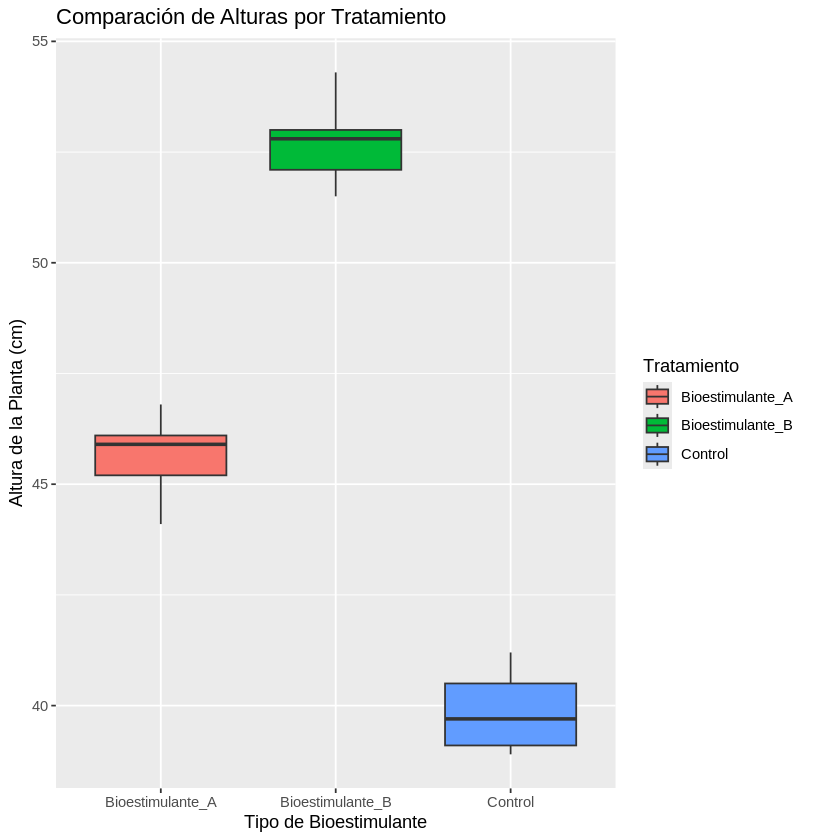

In [ ]:
# --- NIVEL 2: GRÁFICO INTERMEDIO ---
# Agregamos color por tratamiento y personalizamos las etiquetas de los ejes

ggplot(data = datos_experimento, aes(x = Tratamiento, y = Altura, fill = Tratamiento)) +
  geom_boxplot() +
  labs(
    title = "Comparación de Alturas por Tratamiento",
    x = "Tipo de Bioestimulante",
    y = "Altura de la Planta (cm)"
  )

#### Nivel 3: El Gráfico Avanzado (Estilo Científico para Reportes)
En la práctica científica, un gráfico de cajas por sí solo puede ocultar información (como el tamaño de muestra real o la dispersión exacta de los datos). El nivel avanzado combina el boxplot con los puntos individuales reales, mejora la paleta de colores y elimina elementos redundantes.

* **Anatomía del código:**
  * `outlier.shape = NA` dentro de `geom_boxplot()` evita que los puntos atípicos se dibujen dos veces (una por la caja y otra por los puntos individuales).
  * `geom_jitter()` dibuja los datos reales de cada planta con una pequeña dispersión horizontal para evitar que se superpongan.
  * `scale_fill_brewer(palette = "Set2")` aplica una paleta de colores armoniosa predefinida.
  * `theme_minimal()` limpia el fondo gris y las cuadrículas pesadas por defecto.
  * `theme(legend.position = "none")` elimina la leyenda de la derecha, ya que el eje X ya indica claramente el nombre de cada tratamiento, evitando redundancia.

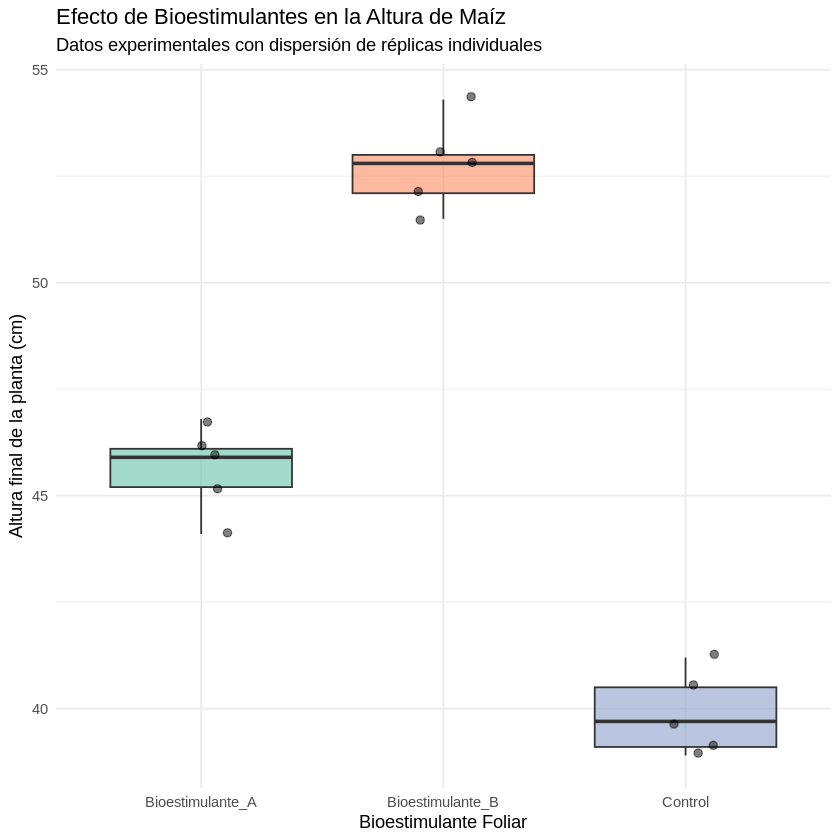

In [ ]:
# --- NIVEL 3: GRÁFICO AVANZADO ---
# Combinación de caja, datos crudos, paleta de colores científica y remoción de redundancias

ggplot(data = datos_experimento, aes(x = Tratamiento, y = Altura, fill = Tratamiento)) +
  # Dibujamos las cajas con 60% de opacidad (alpha) y ocultamos los outliers predeterminados
  geom_boxplot(alpha = 0.6, outlier.shape = NA) +

  # Superponemos los puntos individuales reales
  geom_jitter(width = 0.12, size = 2, color = "black", alpha = 0.5) +

  # Cambiamos la paleta de colores predeterminada por una profesional (Set2)
  scale_fill_brewer(palette = "Set2") +

  # Personalizamos los títulos y subtítulos
  labs(
    title = "Efecto de Bioestimulantes en la Altura de Maíz",
    subtitle = "Datos experimentales con dispersión de réplicas individuales",
    x = "Bioestimulante Foliar",
    y = "Altura final de la planta (cm)"
  ) +

  # Aplicamos un tema visual limpio
  theme_minimal() +

  # Removemos la leyenda lateral redundante para maximizar el área del gráfico
  theme(legend.position = "none")

### LECCIÓN 3: El Ajuste del Modelo

Antes de hacer un ANOVA, R necesita calcular matemáticamente las desviaciones y las medias de los grupos. Esto se llama **Ajustar el modelo**.

* Usamos la función `aov()` (Analysis of Variance).
* Requiere dos ingredientes principales dentro de sus paréntesis:
  1. La **Fórmula** (`Variable_Y ~ Variable_X`).
  2. El **Conjunto de datos** (`data = tu_tabla`).

Guardamos este resultado en un objeto llamado `modelo_ajustado` para poder interrogarlo después.

In [ ]:
# 1. Ajustar el modelo usando aov()
modelo_ajustado <- aov(Altura ~ Tratamiento, data = datos_experimento)

# 2. Solicitar la tabla de resumen del ANOVA usando summary()
# La función summary() traduce el objeto complejo en la clásica tabla ANOVA que conocemos en clase.
summary(modelo_ajustado)

            Df Sum Sq Mean Sq F value   Pr(>F)    
Tratamiento  2  415.0  207.52   201.3 5.87e-10 ***
Residuals   12   12.4    1.03                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### LECCIÓN 4: Validación de Supuestos

El ANOVA solo es válido si sus **residuos** (el error o la distancia entre lo observado y la media del tratamiento) se comportan bien.

#### 1. ¿Cómo extraemos los residuos?
Usamos la función `residuals(modelo_ajustado)`. R calcula automáticamente los residuos de cada planta evaluada.

#### 2. Prueba de Shapiro-Wilk (`shapiro.test`)
* **Propósito:** Evaluar si los residuos tienen una distribución normal.
* **¿Qué buscar?** Si el **p-valor > 0.05**, celebramos, porque significa que los residuos se distribuyen de forma normal.

#### 3. Prueba de Bartlett (`bartlett.test`)
* **Propósito:** Evaluar si todos los tratamientos tienen varianzas homogéneas.
* **¿Qué buscar?** Si el **p-valor > 0.05**, las varianzas son iguales (homocedasticidad).

In [ ]:
# 1. Extracción de residuos
residuos_calculados <- residuals(modelo_ajustado)

# 2. Prueba de normalidad de Shapiro-Wilk
# Le pasamos únicamente el vector de residuos obtenido
test_normalidad <- shapiro.test(residuos_calculados)
print(test_normalidad)

# 3. Prueba de homogeneidad de varianza de Bartlett
# Bartlett requiere que usemos la misma fórmula que el ANOVA original
test_varianzas <- bartlett.test(Altura ~ Tratamiento, data = datos_experimento)
print(test_varianzas)


	Shapiro-Wilk normality test

data:  residuos_calculados
W = 0.97166, p-value = 0.8819


	Bartlett test of homogeneity of variances

data:  Altura by Tratamiento
Bartlett's K-squared = 0.028987, df = 2, p-value = 0.9856



### LECCIÓN 5: Diagnóstico visual avanzado con `performance`

Hacer gráficos de residuos de forma manual requiere mucho código complejo. La librería **`performance`** (parte del ecosistema de ciencia de datos `easystats`) simplifica esto con una sola función llamada `check_model()`.

Esta función analiza el modelo ajustado y crea un reporte visual interactivo de todos los supuestos.

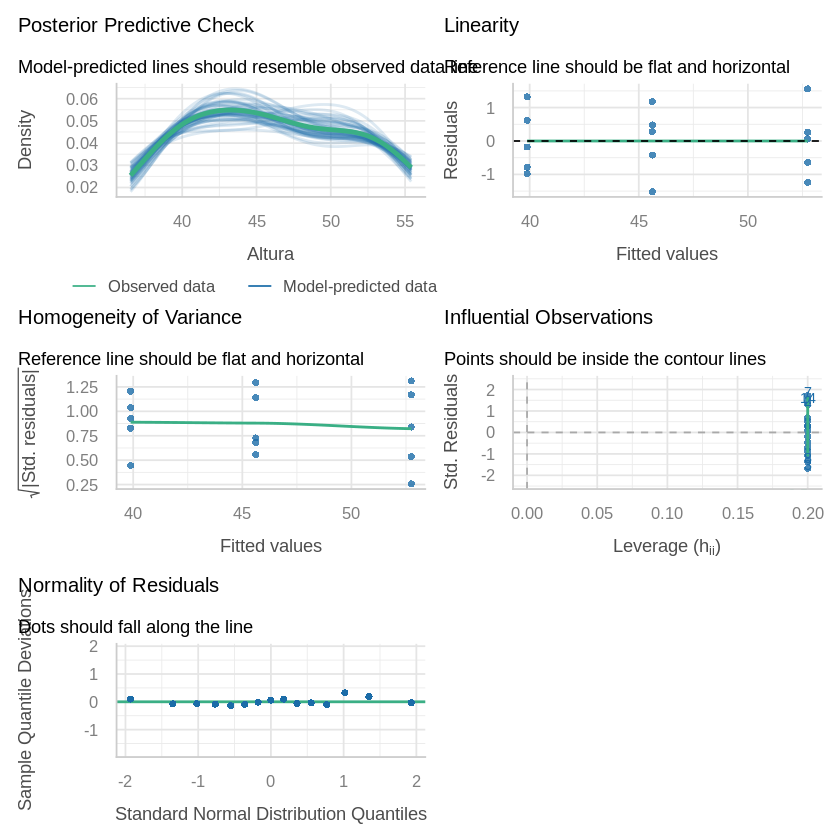

In [ ]:
# Cargamos las librerías necesarias
library(performance)
library(see)

# Ejecutamos el diagnóstico visual completo.
# ¡Solo requiere que le pases el objeto de tu modelo ajustado!
# plot(modelo_ajustado)
check_model(modelo_ajustado)

# GUÍA DE ESTUDIO: ¿Para qué sirve cada prueba y cómo se interpreta?

Cuando evaluamos supuestos, realizamos pruebas de hipótesis específicas. Es crucial entender qué significa el **p-valor (p-value)** obtenido en cada una:

### 1. Prueba de Normalidad de Shapiro-Wilk (`shapiro.test`)
* **¿Qué evalúa?** Si los residuos del modelo siguen una distribución normal (forma de campana de Gauss).
* **Hipótesis:**
  * $H_0$: Los residuos **sí** se distribuyen normalmente.
  * $H_1$: Los residuos **no** se distribuyen normalmente.
* **Regla de decisión:**
  * Si el **p-valor > 0.05**: Se cumple el supuesto (no rechazamos $H_0$). Los datos son normales.
  * Si el **p-valor < 0.05**: No se cumple el supuesto. Hay desviación de la normalidad.

### 2. Prueba de Homocedasticidad de Bartlett (`bartlett.test`)
* **¿Qué evalúa?** Si las varianzas de los diferentes grupos de tratamiento son estadísticamente iguales (homogéneas).
* **Hipótesis:**
  * $H_0$: Las varianzas de los tratamientos **sí** son iguales.
  * $H_1$: Al menos un tratamiento tiene una varianza distinta.
* **Regla de decisión:**
  * Si el **p-valor > 0.05**: Se cumple el supuesto. Hay homogeneidad de varianzas.
  * Si el **p-valor < 0.05**: No se cumple el supuesto. Existe heterocedasticidad (varianzas desiguales).

# **1.3 MÓDULO ADICIONAL: La Piedra Angular del Diseño Experimental — Unidad Experimental vs. Unidad de Muestreo y el Peligro de la Pseudorreplicación**

En el diseño y análisis de experimentos, uno de los errores conceptuales y metodológicos más graves (y lamentablemente comunes) es confundir el objeto sobre el cual **medimos** con el objeto sobre el cual **aplicamos los tratamientos**. Esta confusión invalida los análisis estadísticos tradicionales como el ANOVA y conduce a conclusiones científicas erróneas. Este fenómeno se conoce en la literatura como **Pseudorreplicación** (Hurlbert, 1984).

---

### **1.3.1 Conceptos Fundamentales**

*   **Unidad Experimental (UE):** Es la entidad física mínima a la que se le asigna un tratamiento de manera completamente **aleatoria e independiente**. La variación entre diferentes unidades experimentales independientes constituye el verdadero **error experimental** (que actúa como el "ruido de fondo" o denominador en las pruebas $F$ del ANOVA).
*   **Unidad de Muestreo (UM):** Es la entidad física o porción de la unidad experimental en la que realmente se realiza la medición de la variable de respuesta.

> [!IMPORTANT]
> **La clave de la réplica verdadera es la independencia en la asignación del tratamiento.** Si dos observaciones provienen de un entorno donde compartieron la misma aplicación física del tratamiento y las mismas microcondiciones ambientales sin aleatorización intermedia, **no son réplicas independientes**, son submuestras.

---

### **1.3.2 Ejemplo Práctico en Ciencias Agropecuarias y Biológicas**

Imagine que queremos evaluar el efecto de un **Bioestimulante foliar** frente a un **Control de agua**.
*   **Tratamientos:** Control vs. Bioestimulante (2 niveles).
*   **Diseño:** Contamos con **6 macetas** en total (3 asignadas al azar para Control, 3 para Bioestimulante).
*   **Cultivo:** En cada maceta sembramos **4 plantas de maíz**.
*   **Medición:** Al final del ensayo, medimos la altura de **las 4 plantas** en cada maceta, obteniendo **24 mediciones** en total.

**¿Cuáles son las unidades reales en este experimento?**
*   **Unidad Experimental (UE):** La **Maceta**. El bioestimulante se atomiza a nivel de maceta o se aplica en su suelo. Las 4 plantas dentro de una misma maceta comparten el mismo sustrato, la misma humedad, el mismo riego y la misma dosis exacta del tratamiento. Están correlacionadas.
*   **Unidad de Muestreo (UM):** La **Planta individual**. Mide la respuesta, pero su comportamiento no es independiente de sus compañeras de maceta.

---

### **1.3.3 El Gran Peligro: La Pseudorreplicación**

Si introducimos las 24 mediciones individuales en un ANOVA estándar asumiendo que tenemos 24 réplicas independientes, cometemos **Pseudorreplicación**:
1.  **Inflación artificial del tamaño muestral ($N$):** Creemos tener $N = 24$ unidades experimentales independientes, cuando en realidad solo tenemos $N = 6$.
2.  **Inflación de los Grados de Libertad del Error ($df_{\text{error}}$):** El ANOVA calcula $df_{\text{error}} = N - k = 24 - 2 = 22$. En realidad, deberíamos tener $df_{\text{error}} = 6 - 2 = 4$.
3.  **Subestimación del Error Residual:** Al ignorar que las plantas dentro de una misma maceta se parecen más entre sí que a plantas de otras macetas, subestimamos la variabilidad real entre UEs. Esto reduce artificialmente el Error Cuadrático Medio residual ($MS_{\text{error}}$).
4.  **Falsos Positivos (Error Tipo I):** Con un denominador ($MS_{\text{error}}$) artificialmente pequeño y unos grados de libertad inflados, el estadístico $F$ se dispara y los **p-valores se vuelven minúsculos**, declarando significancia donde quizás no la hay.

---

### **1.3.4 Demostración Práctica en R (Simulación)**

A continuación, ejecutaremos una simulación en la que generaremos datos realistas con "efecto maceta" (correlación interna). Compararemos el **análisis incorrecto (pseudorreplicado)** con el **análisis correcto (agregado por Unidad Experimental)** para ver el impacto real en los grados de libertad, el error residual y la decisión del p-valor.


In [ ]:
# ==============================================================================
# DEMOSTRACIÓN DE PSEUDORREPLICACIÓN EN R
# ==============================================================================

# 1. SIMULACIÓN DE DATOS CON CORRELACIÓN INTERNA (EFECTO MACETA)
# ------------------------------------------------------------------------------
set.seed(123) # Para reproducibilidad

# Estructura del experimento:
# 2 tratamientos, 3 macetas por tratamiento (6 UEs en total), 4 plantas por maceta (24 UMs en total)
datos_experimento <- data.frame(
  Planta_ID = 1:24,
  Tratamiento = rep(c("Control", "Bioestimulante"), each = 12),
  Maceta = rep(paste0("Maceta_", 1:6), each = 4)
)

# Generamos un efecto aleatorio para cada maceta (diferencias biológicas reales entre macetas)
# Esto simula que algunas macetas retienen mejor el agua o tienen mejor exposición que otras.
efecto_maceta <- rep(rnorm(6, mean = 0, sd = 1.8), each = 4)

# Error individual de cada planta (ruido interno dentro de la maceta)
ruido_planta <- rnorm(24, mean = 0, sd = 0.5)

# Altura final de las plantas:
# Media base de 15 cm. Sumamos un efecto real muy pequeño de tratamiento (+0.5 cm)
# sumado al efecto de su maceta y al ruido de la planta.
datos_experimento$Altura <- 15 + 
  ifelse(datos_experimento$Tratamiento == "Bioestimulante", 0.5, 0) + 
  efecto_maceta + 
  ruido_planta

# Mostramos los primeros datos del experimento
cat("--- ESTRUCTURA DE LOS DATOS CRUDOS (PRIMERAS 8 FILAS) ---\n")
print(head(datos_experimento, 8))

# 2. ANÁLISIS INCORRECTO: PSEUDORREPLICACIÓN (Tratar plantas como UEs independientes)
# ------------------------------------------------------------------------------
# En este análisis, ignoramos la existencia de las macetas y asumimos N = 24.
modelo_incorrecto <- aov(Altura ~ Tratamiento, data = datos_experimento)
anova_incorrecto <- summary(modelo_incorrecto)

cat("\n======================================================================\n")
cat("=== ANÁLISIS INCORRECTO: ANOVA PSEUDORREPLICADO (N = 24 plantas) ===\n")
cat("======================================================================\n")
print(anova_incorrecto)

# 3. ANÁLISIS CORRECTO: AGREGACIÓN POR UNIDAD EXPERIMENTAL (MACETA)
# ------------------------------------------------------------------------------
# Para corregir la pseudorreplicación de forma clásica, debemos calcular el promedio
# de las plantas dentro de cada maceta. Así obtenemos un único valor por UE (N = 6).
datos_agregados <- aggregate(Altura ~ Tratamiento + Maceta, data = datos_experimento, FUN = mean)

cat("\n--- DATOS AGREGADOS POR MACETA (VERDADERAS UNIDADES EXPERIMENTALES) ---\n")
print(datos_agregados)

# Ejecutamos el ANOVA sobre los datos promedio de las macetas
modelo_correcto <- aov(Altura ~ Tratamiento, data = datos_agregados)
anova_correcto <- summary(modelo_correcto)

cat("\n======================================================================\n")
cat("=== ANÁLISIS CORRECTO: ANOVA BASADO EN UNIDADES EXPERIMENTALES (N = 6) ===\n")
cat("======================================================================\n")
print(anova_correcto)

# 4. CONCLUSIÓN Y REFLEXIÓN PEDAGÓGICA
# ------------------------------------------------------------------------------
# Comparemos los grados de libertad de los residuos y el p-valor obtenido.
cat("\n======================================================================\n")
cat("=== COMPARATIVA DE RESULTADOS ===\n")
cat("======================================================================\n")
cat(sprintf("• ANOVA Pseudorreplicado: Df Residuos = %d, p-valor = %f\n", 
            anova_incorrecto[[1]][["Df"]][2], anova_incorrecto[[1]][["Pr(>F)"]][1]))
cat(sprintf("• ANOVA Correcto (Agregado): Df Residuos = %d, p-valor = %f\n", 
            anova_correcto[[1]][["Df"]][2], anova_correcto[[1]][["Pr(>F)"]][1]))
cat("\n--- DIAGNÓSTICO ESTADÍSTICO ---\n")
cat("1. En el ANOVA incorrecto, el p-valor es bajo y da una falsa sensación de significancia\n")
cat("   porque inflamos artificialmente los Df de 4 a 22 (subestimando el error real).\n")
cat("2. En el ANOVA correcto, con Df = 4, vemos la realidad: no hay evidencia estadística suficiente\n")
cat("   de un efecto del bioestimulante. Necesitaríamos más macetas (más UEs), no más plantas por maceta.\n")


## TALLER PRÁCTICO EN CLASE

**Objetivo:** Basándote en las lecciones anteriores, debes rellenar los espacios vacíos (`___`) del siguiente código para analizar un experimento de control de plagas.

**Contexto del experimento:** Un entomólogo evalúa el número de insectos sobrevivientes tras aplicar 3 insecticidas diferentes (Químico, Orgánico, Botánico) en parcelas de cultivo.

In [ ]:
# --- DATOS DEL EXPERIMENTO (NO MODIFICAR ESTE BLOQUE) ---
set.seed(777)
datos_plaga <- data.frame(
  Insecticida = factor(rep(c("Quimico", "Organico", "Botanico"), each = 6)),
  Insectos = c(rnorm(6, mean = 5, sd = 1.2),     # Quimico
               rnorm(6, mean = 12, sd = 1.5),    # Organico
               rnorm(6, mean = 18, sd = 2.0))    # Botanico
)

# ==============================================================
# PASO 1: Graficar usando ggplot2
# Instrucción: Reemplaza los "___" con las variables correspondientes
# (X = Insecticida, Y = Insectos, fill = Insecticida)
# ==============================================================
ggplot(datos_plaga, aes(x = ___, y = ___, fill = ___)) +
  geom_boxplot() +
  labs(title = "Efectividad de Insecticidas", x = "Tipo de Insecticida", y = "Número de Insectos")

# ==============================================================
# PASO 2: Ajustar el Modelo Lineal
# Instrucción: Reemplaza "___" con la fórmula del modelo (Insectos depende de Insecticida)
# ==============================================================
modelo_plaga <- aov(___ ~ ___, data = datos_plaga)
summary(modelo_plaga)

# ==============================================================
# PASO 3: Validación del Supuesto de Normalidad
# Instrucción: Extrae los residuos del modelo de plagas usando la función 'residuals'
# y luego pásalos a la función 'shapiro.test'
# ==============================================================
residuos_plaga <- residuals(___)
shapiro.test(___)

# ==============================================================
# PASO 4: Validación del Supuesto de Homocedasticidad
# Instrucción: Reemplaza "___" para ejecutar el test de Bartlett
# ==============================================================
bartlett.test(Insectos ~ Insecticida, data = ___)

**Contexto del experimento:** Análisis del efecto de los nutrientes en plantas

In [ ]:
# --- CONJUNTO DE DATOS (NO MODIFICAR ESTE BLOQUE) ---
set.seed(2026)
datos_taller <- data.frame(
  Tratamiento = factor(rep(c("Trat_A", "Trat_B", "Trat_C"), each = 6)),
  Peso = c(12.1, 11.5, 12.8, 11.9, 13.0, 12.4,  # Trat_A
           18.5, 19.2, 17.8, 18.0, 19.9, 18.7,  # Trat_B
           15.1, 14.8, 16.2, 15.5, 14.9, 15.3)   # Trat_C
)

# ==========================================
# PASO 1: Análisis Exploratorio Visual
# Instrucción: Completa el gráfico con ggplot2 indicando qué variable va en el eje X y cuál en el eje Y.
# RELLENA LOS ESPACIOS VACÍOS CON: 'Tratamiento' y 'Peso'
# ==========================================
ggplot(datos_taller, aes(x = ___, y = ___, fill = Tratamiento)) +
  geom_boxplot() +
  labs(title = "Exploración de Pesos de Planta", x = "Tratamientos", y = "Peso (g)")

# ==========================================
# PASO 2: Ajuste del Modelo Lineal (ANOVA)
# Instrucción: Ajusta el modelo de análisis de varianza utilizando la función aov().
# RELLENA EL ESPACIO: Escribe la fórmula 'Peso ~ Tratamiento'
# ==========================================
modelo_taller <- aov(___, data = datos_taller)
summary(modelo_taller)

# ==========================================
# PASO 3: Validación Numérica de los Supuestos
# Instrucción: Extrae los residuos del modelo y ejecuta el test de Shapiro-Wilk.
# RELLENA LOS ESPACIOS VACÍOS
# ==========================================
residuos_taller <- residuals(___)

# Ejecuta el test de normalidad para los residuos del taller
shapiro.test(___)

# Ejecuta el test de Bartlett para verificar homogeneidad de varianzas
# Recuerda usar la fórmula 'Peso ~ Tratamiento'
bartlett.test(___, data = datos_taller)